# IMPORT THE LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD THE DATASET

In [2]:
df = pd.read_csv('Wholesale customers data.csv') 

In [3]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


# INFORMATION RELATED TO DATA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
df.isnull().sum

<bound method DataFrame.sum of      Channel  Region  Fresh   Milk  Grocery  Frozen  Detergents_Paper  \
0      False   False  False  False    False   False             False   
1      False   False  False  False    False   False             False   
2      False   False  False  False    False   False             False   
3      False   False  False  False    False   False             False   
4      False   False  False  False    False   False             False   
..       ...     ...    ...    ...      ...     ...               ...   
435    False   False  False  False    False   False             False   
436    False   False  False  False    False   False             False   
437    False   False  False  False    False   False             False   
438    False   False  False  False    False   False             False   
439    False   False  False  False    False   False             False   

     Delicassen  
0         False  
1         False  
2         False  
3         False  
4 

 * NO NULL VALUES

In [7]:
df.mean(axis=0)

Channel                 1.322727
Region                  2.543182
Fresh               12000.297727
Milk                 5796.265909
Grocery              7951.277273
Frozen               3071.931818
Detergents_Paper     2881.493182
Delicassen           1524.870455
dtype: float64

In [8]:
df.value_counts()

Channel  Region  Fresh  Milk   Grocery  Frozen  Detergents_Paper  Delicassen
2        3       12669  9656   7561     214     2674              1338          1
                 7057   9810   9568     1762    3293              1776          1
                 6353   8808   7684     2405    3516              7844          1
1        3       13265  1196   4221     6404    507               1788          1
2        3       22615  5410   7198     3915    1777              5185          1
                                                                               ..
1        3       29703  12051  16027    13135   182               2204          1
                 39228  1431   764      4510    93                2346          1
2        3       14531  15488  30243    437     14841             1867          1
1        3       10290  1981   2232     1038    168               2125          1
                 2787   1698   2510     65      477               52            1
Name: count, Length: 

# Plotting different figures

## Histogram

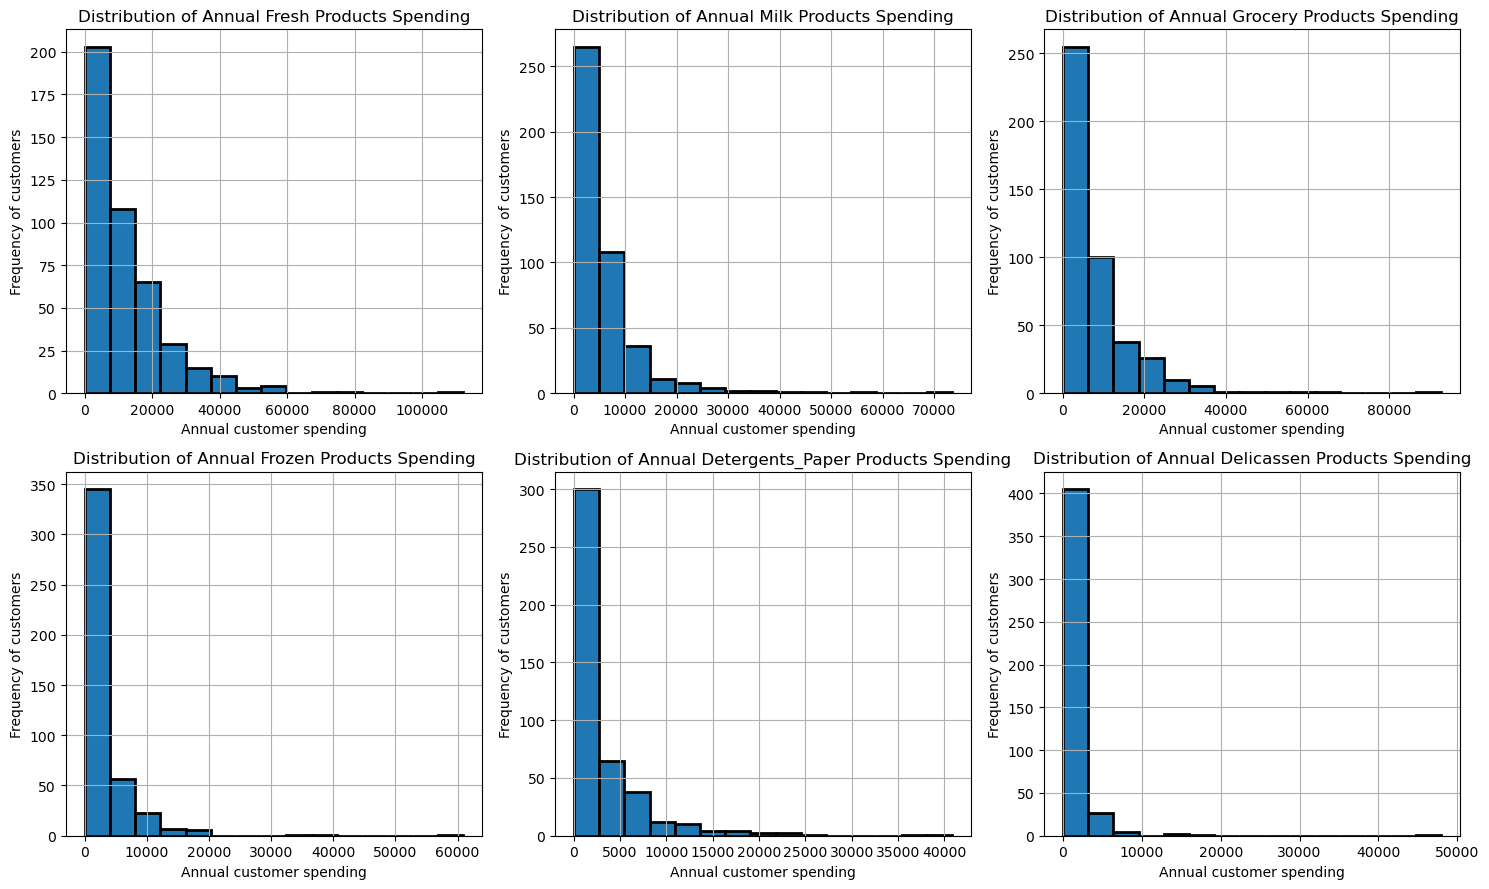

In [9]:
cols = ['Fresh', 'Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
fig, ax = plt.subplots(2,3,figsize=(15, 9))
style = {'edgecolor': 'black', 'linewidth': 2}
for idx,val in enumerate(cols):
    row = idx // 3
    col = idx % 3
    ax[row][col].set_title(f'Distribution of Annual {val} Products Spending')
    ax[row][col].hist(df[val],bins=15,**style)
    ax[row][col].set_xlabel('Annual customer spending')
    ax[row][col].set_ylabel('Frequency of customers')
    ax[row][col].grid()
    
plt.tight_layout()
plt.show()

### Feature Name: Fresh

#### Statistical Observation
- The distribution skewed to the right.
- There are extreme values beyond 100000.
- Most of the observations are concentrated to the left.

#### Business Interpretation
- Most customers spend relatively small amounts, while a small number of customers make exceptionally large purchases.
- This suggests the presence of a few high-value wholesale clients alongside many regular customers.
- These premium customers may require dedicated account management or personalized marketing strategies.

#### Machine Learning Implication
- This distribution affect a distance-based algorithm like K-Means
- The extreme spending values may disproportionately influence the position of cluster centroids, potentially resulting in clusters that are driven by a few high-value customers rather than the overall customer population. Therefore, feature scaling and further investigation of the distribution should be considered before applying K-Means clustering.
______________________________________________________________________________________________________________

### Feature Name: Milk

#### Statistical Observation
- The distribution skewed to the right.
- There are extreme values upto 70000.
- Most customers spend less than approximately 10,000 monetary units on milk products, while only a small proportion of customers spend significantly higher amounts. The distribution has a long right tail extending to nearly 70,000 monetary units, indicating the presence of high-spending customers.

#### Business Interpretation
- Customers with exceptionally high milk purchases may include hotels, restaurants, cafés, bakeries, or large grocery retailers that require continuous supplies of dairy products. These customers are likely to generate significant revenue and may benefit from customized pricing, dedicated account managers, or long-term supply contracts.
- This suggests the presence of a few high-value wholesale clients alongside many regular customers.
- These premium customers may require dedicated account management or personalized marketing strategies.

#### Machine Learning Implication
- This distribution affect a distance-based algorithm like K-Means
- The extreme spending values may disproportionately influence the position of cluster centroids, potentially resulting in clusters that are driven by a few high-value customers rather than the overall customer population. Therefore, feature scaling and further investigation of the distribution should be considered before applying K-Means clustering.
______________________________________________________________________________________________________________

### Feature Name: Grocery

#### Statistical Observation

* The distribution of annual spending on grocery products is highly right-skewed.
* Most customers spend relatively small amounts on grocery products, while a few customers have exceptionally high spending levels.
* The long right tail indicates the presence of customers with significantly higher grocery purchases compared to the majority.

#### Business Interpretation

* Customers with high grocery expenditures are likely to be supermarkets, wholesale retailers, or businesses that require frequent replenishment of grocery products.
* These high-value customers contribute significantly to overall revenue and may benefit from personalized pricing, volume-based discounts, and dedicated relationship managers.
* The company can also use this information to forecast inventory requirements and prioritize service for high-volume customers.

#### Machine Learning Implication

* The highly skewed distribution indicates that a few customers have substantially larger grocery expenditures than the majority.
* Since K-Means relies on Euclidean distance, these extreme observations may disproportionately influence cluster centroids.
* Appropriate preprocessing, such as feature scaling and further analysis of the distribution, should therefore be considered before clustering.
______________________________________________________________________________________________________________


### Feature Name: Frozen

#### Statistical Observation

* The annual spending on frozen products is highly right-skewed.
* Most customers spend relatively small amounts on frozen products, while only a few customers make very large purchases.
* The distribution suggests that high frozen-product purchases are concentrated among a small segment of customers.

#### Business Interpretation

* Customers with high frozen product purchases may include restaurants, hotels, food processing businesses, and large retailers requiring continuous frozen inventory.
* These customers may represent premium business accounts with recurring purchasing needs.
* Identifying such customers allows the company to optimize cold-chain logistics, improve inventory planning, and design targeted promotional offers.

#### Machine Learning Implication

* The presence of a few customers with exceptionally large frozen-product expenditures can strongly influence distance calculations in K-Means clustering.
* Without appropriate preprocessing, clusters may become biased toward these high-spending customers.
* Feature scaling should therefore be performed before clustering to ensure that all spending categories contribute fairly to cluster formation.
______________________________________________________________________________________________________________


### Feature Name: Detergents_Paper

#### Statistical Observation

* The distribution of annual spending on detergents and paper products is highly right-skewed.
* Most customers exhibit relatively low spending levels, while a small number of customers purchase these products in significantly larger quantities.
* The long right tail indicates the presence of customers with exceptionally high expenditures.

#### Business Interpretation

* High-spending customers are likely to include supermarkets, wholesale distributors, hospitals, hotels, and institutional buyers that regularly consume cleaning and paper products.
* These customers represent valuable long-term business opportunities and may benefit from customized contracts, bulk purchase incentives, and priority service.
* Understanding this spending pattern also supports demand forecasting and inventory management.

#### Machine Learning Implication

* The skewed distribution suggests that a small number of customers may have a disproportionate influence on the cluster centroids.
* Since K-Means is a distance-based algorithm, these high-value observations can significantly affect cluster formation.
* Appropriate preprocessing techniques should therefore be considered to improve clustering performance.
______________________________________________________________________________________________________________


### Feature Name: Delicassen

#### Statistical Observation

* The annual spending on delicassen products is highly right-skewed.
* The majority of customers spend relatively little on delicassen products, while only a few customers account for very high expenditures.
* The distribution contains a long right tail, indicating substantial variability among customer spending patterns.

#### Business Interpretation

* Customers with high delicassen spending may include premium hotels, luxury restaurants, gourmet food retailers, and specialty food distributors.
* These customers represent niche but potentially high-profit market segments.
* The company can design premium loyalty programs, exclusive product offerings, and personalized marketing campaigns to strengthen relationships with these customers.

#### Machine Learning Implication

* The large variation in spending may cause high-value customers to exert greater influence during centroid calculation in K-Means clustering.
* Appropriate preprocessing and feature scaling should therefore be considered to reduce the impact of large spending differences.
* This helps produce more balanced and meaningful customer segments.

## Boxplot

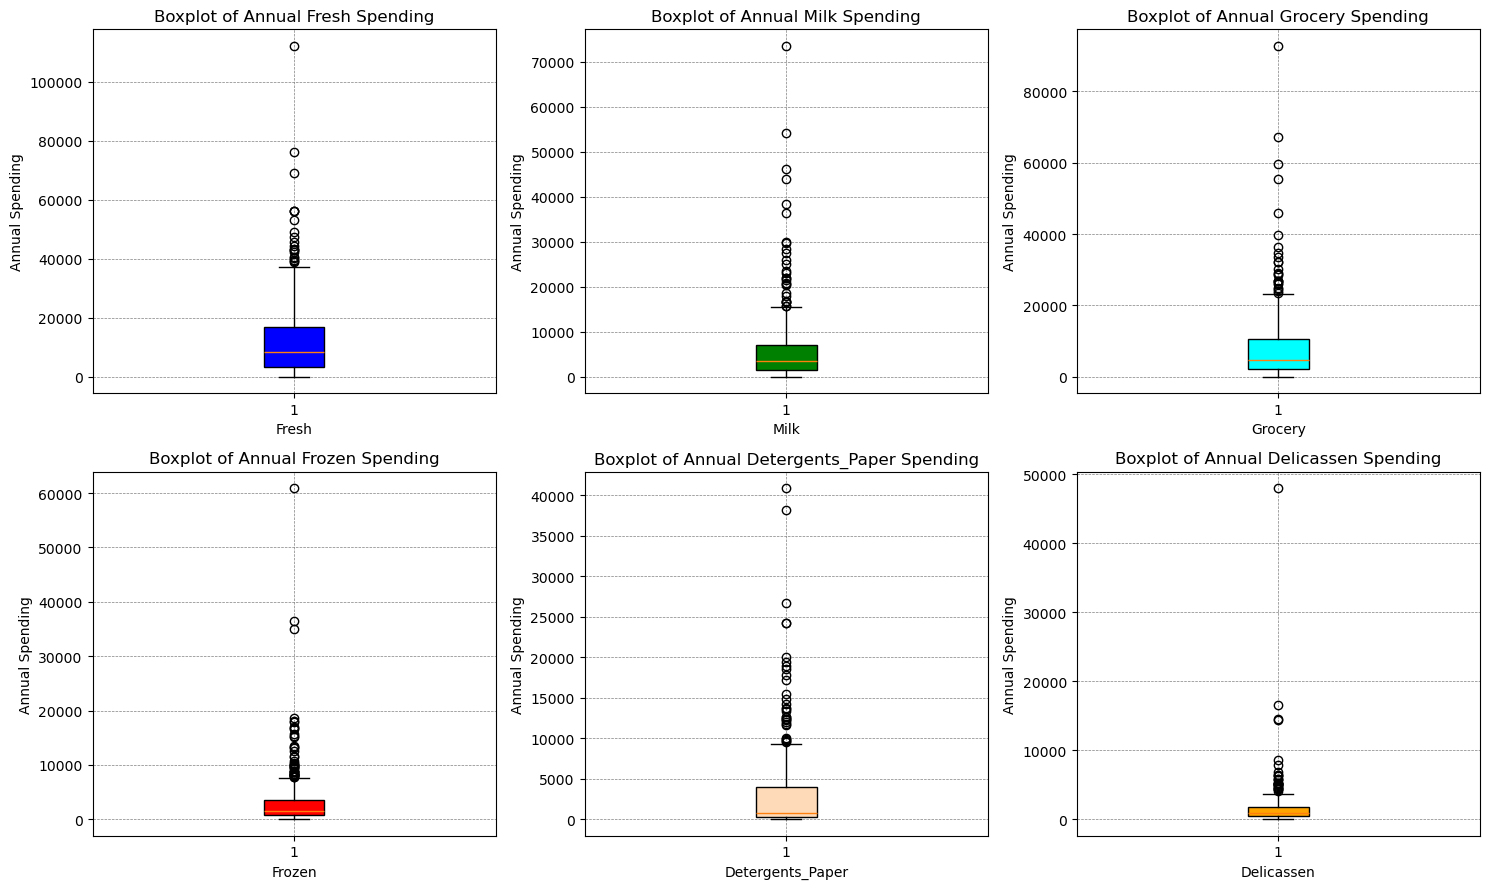

In [10]:
cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
colors = ['blue', 'green', 'cyan', 'red', 'peachpuff', 'orange']

for idx, val in enumerate(cols):
    row = idx // 3
    col = idx % 3
    current_ax = ax[row][col]
    current_ax.set_title(f'Boxplot of Annual {val} Spending')
    bplot = current_ax.boxplot(x=df[val], patch_artist=True)
    current_ax.set_xlabel(val)
    current_ax.set_ylabel('Annual Spending')
    current_ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
    
    for patch in bplot['boxes']:
        patch.set_facecolor(colors[idx])

plt.tight_layout()
plt.show()

## Fresh
Fresh spending has a wide middle range and many high-value potential outliers, including one customer above roughly 100,000.
This suggests that most customers purchase modest amounts of fresh products, while a small but important group buys fresh goods in very large volumes. These may be hotels, restaurant chains, caterers, or large retailers. Such accounts could need dependable delivery schedules and dedicated relationship management.

## Milk
Milk spending is concentrated at lower levels for most customers, but several customers spend far more—reaching roughly 70,000 or more.
This indicates a small group with unusually high dairy demand, potentially bakeries, cafés, hotels, restaurants, or large supermarkets. The business could consider volume pricing or recurring supply contracts for them.

## Grocery
Grocery spending also has many upper outliers, with the largest near 90,000–95,000.
The pattern suggests that a small number of customers are major grocery purchasers, likely retail stores or supermarkets. They are strategically valuable for inventory planning, bulk discounts, and account prioritization.

## Frozen
Frozen spending has a relatively compact box near lower values, followed by many upper potential outliers and one very large value around 60,000.
Most customers buy limited frozen products, whereas a small segment purchases them in bulk. This can help the business identify customers needing specialized cold-chain logistics, frequent replenishment, or freezer-related promotional bundles.

## Detergents_Paper
Most customers spend relatively little on detergents and paper products, but there are many high-spending potential outliers, with values above 40,000.
This may indicate institutional or retail buyers—such as supermarkets, hotels, hospitals, and distributors—that consume these supplies at scale. These customers could be suited to bulk contracts and demand forecasting initiatives.

## Delicassen
Delicatessen spending is concentrated at very low values for most customers. However, there are several high-value potential outliers, including one near 48,000.
This points to a niche premium segment: gourmet retailers, premium hotels, restaurants, or specialty distributors. Although smaller in number, these customers may have high margins and could respond well to exclusive product offerings or personalized campaigns.

In [11]:
corr = df[cols].corr()

In [12]:
corr

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicassen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


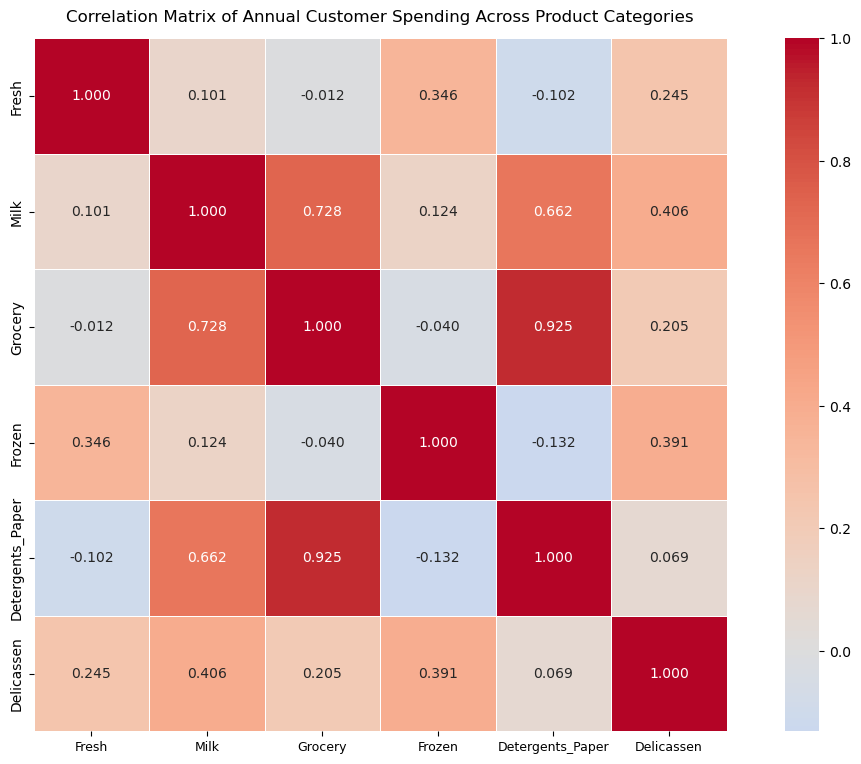

In [13]:
fig, ax = plt.subplots(1,1, figsize=(15, 9))
ax = sns.heatmap(corr, annot=True,fmt=".3f",linewidth=.5,cmap="coolwarm",center=0,square=True)
ax.set_title("Correlation Matrix of Annual Customer Spending Across Product Categories",pad=12)
ax.tick_params(axis='x', labelsize=9)

# Overall Business Insights
The correlation analysis reveals several important customer purchasing patterns:
* Grocery products and Detergents & Paper products are highly complementary and are frequently purchased together.

* Milk purchases strongly align with Grocery purchases, indicating common purchasing requirements among wholesale customers.

* Fresh products demonstrate relatively independent purchasing behavior compared with other categories.

The dataset contains multiple product categories with weak or moderate relationships, suggesting that customers exhibit diverse purchasing behaviors across product groups.
These findings indicate that different customer groups purchase different combinations of products, supporting the need for customer segmentation rather than treating all customers as a homogeneous population.

# DATA PREPROCESSING

In [14]:
df[cols].describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [15]:
for col in cols:
    df[col] = np.log1p(df[col])

In [16]:
df[cols].describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,8.732813,8.121615,8.442205,7.303128,6.791781,6.671094
std,1.470618,1.080635,1.111523,1.281888,1.709519,1.293960
min,1.386294,4.025352,1.386294,3.258097,1.386294,1.386294
25%,8.048378,7.335633,7.675081,6.611024,5.551989,6.014321
50%,9.048404,8.196435,8.467267,7.331043,6.706242,6.873680
75%,9.737123,8.880619,9.273948,8.176177,8.274596,7.507278
max,11.627610,11.205027,11.437997,11.016496,10.617123,10.777789


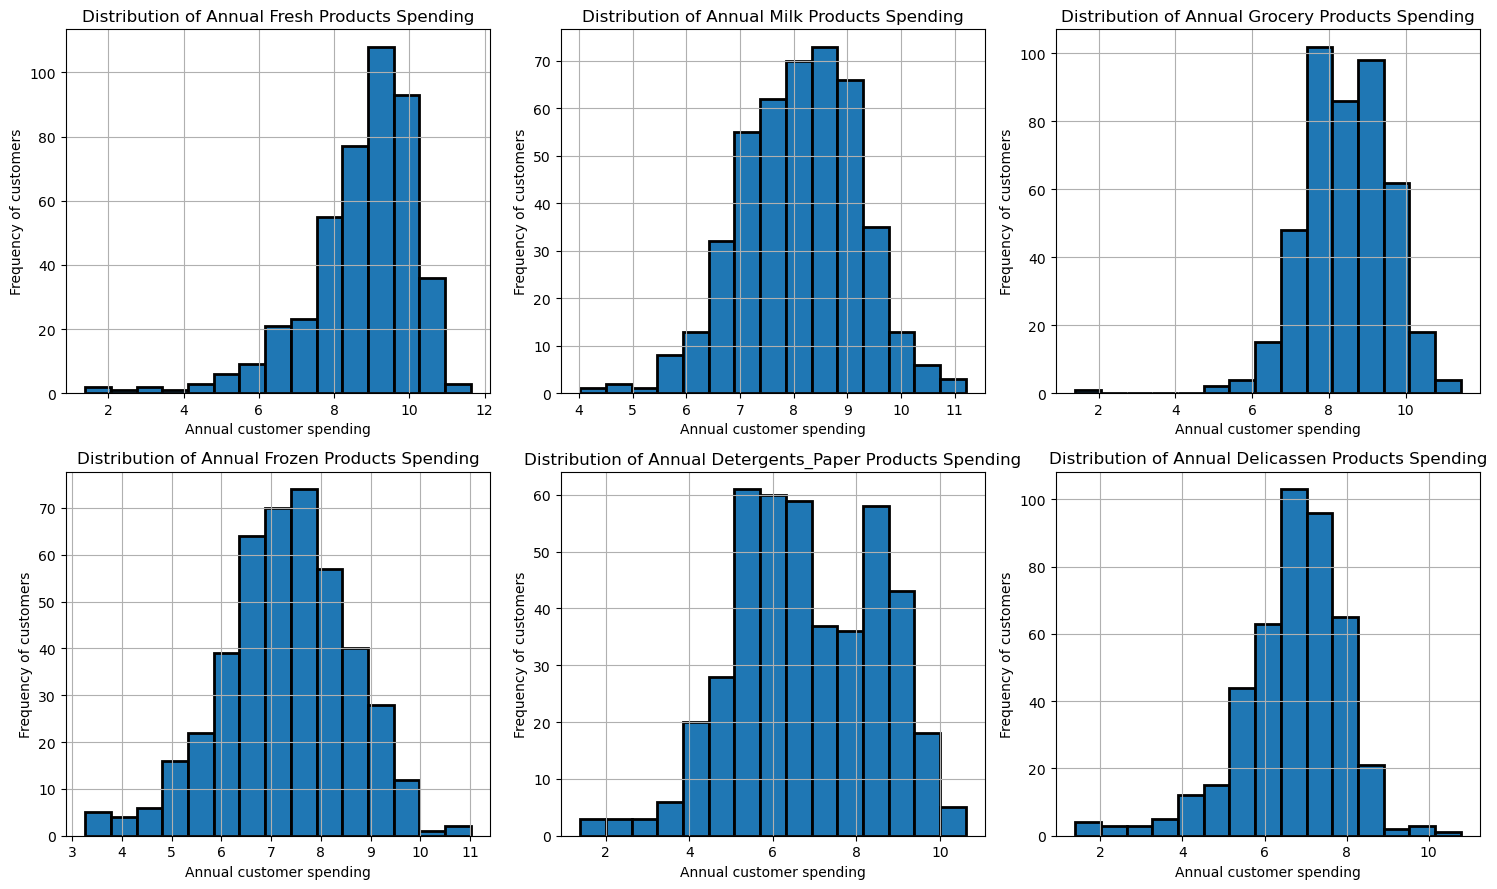

In [17]:
cols = ['Fresh', 'Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
fig, ax = plt.subplots(2,3,figsize=(15, 9))
style = {'edgecolor': 'black', 'linewidth': 2}
for idx,val in enumerate(cols):
    row = idx // 3
    col = idx % 3
    ax[row][col].set_title(f'Distribution of Annual {val} Products Spending')
    ax[row][col].hist(df[val],bins=15,**style)
    ax[row][col].set_xlabel('Annual customer spending')
    ax[row][col].set_ylabel('Frequency of customers')
    ax[row][col].grid()
    
plt.tight_layout()
plt.show()

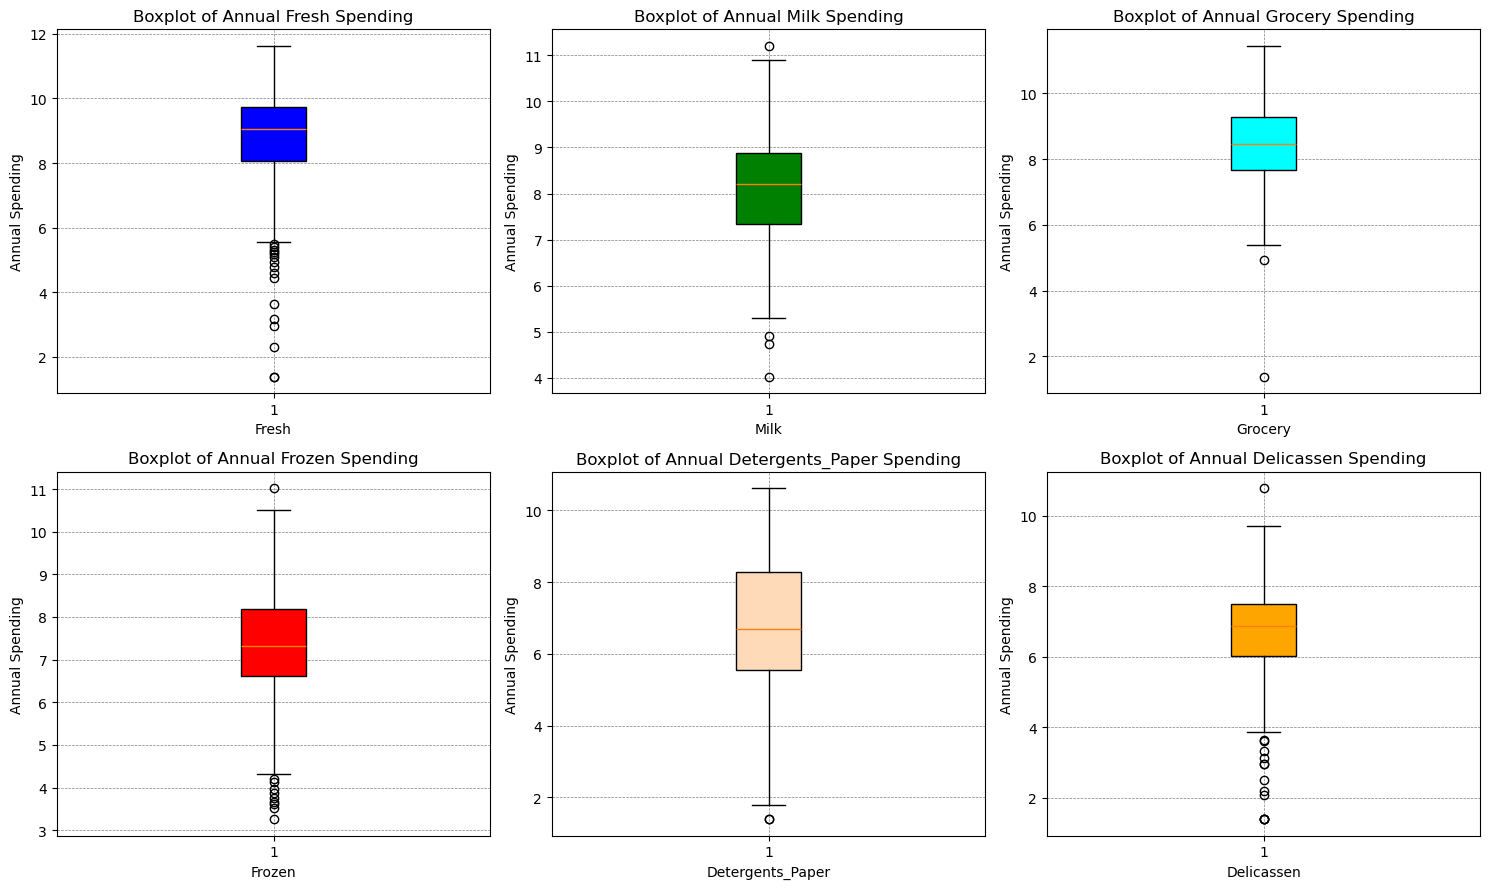

In [18]:
cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
fig, ax = plt.subplots(2, 3, figsize=(15, 9))
colors = ['blue', 'green', 'cyan', 'red', 'peachpuff', 'orange']

for idx, val in enumerate(cols):
    row = idx // 3
    col = idx % 3
    current_ax = ax[row][col]
    current_ax.set_title(f'Boxplot of Annual {val} Spending')
    bplot = current_ax.boxplot(x=df[val], patch_artist=True)
    current_ax.set_xlabel(val)
    current_ax.set_ylabel('Annual Spending')
    current_ax.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
    
    for patch in bplot['boxes']:
        patch.set_facecolor(colors[idx])

plt.tight_layout()
plt.show()

# Scaling the Data

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_array = scaler.fit_transform(df[cols])

scaled_df = pd.DataFrame(
    scaled_array,
    columns=cols,
    index=df.index
)

In [20]:
scaled_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


In [21]:
scaled_df.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02,4.400000e+02
mean,3.229740e-17,-7.105427e-16,-1.081963e-15,2.987509e-16,-6.297992e-16,-2.220446e-17
std,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00,1.001138e+00
min,-5.001217e+00,-3.794924e+00,-6.355190e+00,-3.159118e+00,-3.165591e+00,-4.088856e+00
25%,-4.659360e-01,-7.281616e-01,-6.909415e-01,-5.405240e-01,-7.260542e-01,-5.081462e-01
50%,2.148413e-01,6.931547e-02,2.257341e-02,2.180154e-02,-5.009412e-02,1.567407e-01
75%,6.836939e-01,7.031679e-01,7.491423e-01,6.818408e-01,8.683740e-01,6.469559e-01
max,1.970662e+00,2.856582e+00,2.698281e+00,2.900093e+00,2.240218e+00,3.177354e+00


# Implementing PCA

## PCA Analysis with 5 components

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

pca_features = pca.fit_transform(scaled_df) 

pca_df = pd.DataFrame(

    pca_features,

    columns=[
        'PC1',
        'PC2',
        'PC3',
        'PC4',
        'PC5'
    ]
)
pca_df.head()

,PC1,PC2,PC3,PC4,PC5
0,1.380383,-0.304727,-0.241062,-1.415719,0.331697
1,1.438870,0.537468,0.084232,0.030928,0.110869
2,1.513453,1.232565,0.985306,-0.168522,-0.155481
3,-0.825105,1.210790,0.252141,0.339294,-0.714398
4,0.802897,1.766046,0.312698,-0.234905,-0.260565


In [23]:
# View information retention
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Variance explained by PC3: {pca.explained_variance_ratio_[2]:.2%}")
print(f"Variance explained by PC4: {pca.explained_variance_ratio_[3]:.2%}")
print(f"Variance explained by PC5: {pca.explained_variance_ratio_[4]:.2%}")
print(f"Total variance retained: {np.sum(pca.explained_variance_ratio_):.2%}")


Variance explained by PC1: 44.08%
Variance explained by PC2: 27.19%
Variance explained by PC3: 10.70%
Variance explained by PC4: 10.10%
Variance explained by PC5: 4.88%
Total variance retained: 96.95%


In [24]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.44077752 0.27194917 0.10698428 0.10103287 0.04876269]


In [25]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.44077752 0.71272669 0.81971097 0.92074384 0.96950653]


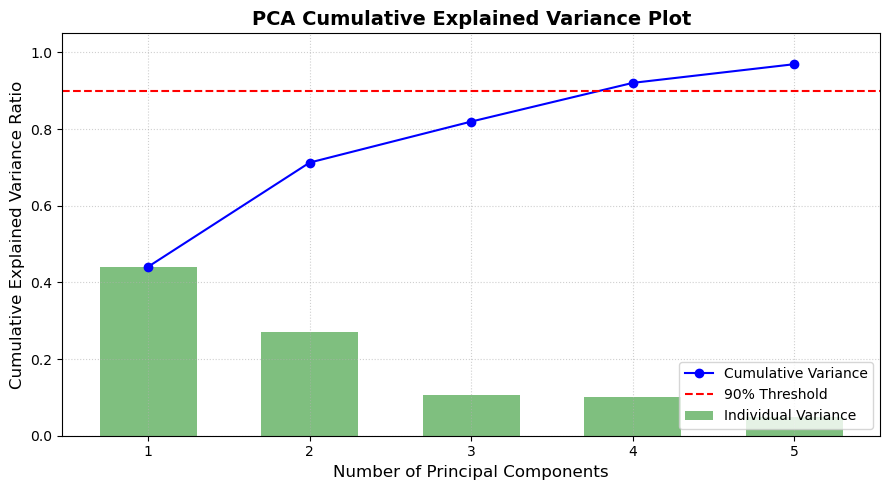

In [26]:
plt.figure(figsize=(9, 5))

# Plot the step or line graph
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='blue', label='Cumulative Variance')
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, color='green', label='Individual Variance',width=0.6)

# Add a threshold line (e.g., 90% variance)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')

# Aesthetics
plt.title('PCA Cumulative Explained Variance Plot', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=12)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')


# Display the plot
plt.tight_layout()
plt.show()


# Business Interpretation
The first four principal components preserve over 90% of the information contained in the six original spending variables. This indicates that customer purchasing behaviour can be effectively summarized using fewer dimensions without losing significant information. Reducing dimensionality simplifies customer analysis while retaining the key spending patterns required for segmentation.

# Machine Learning Interpretation
Since more than 90% of the variance is retained by the first four principal components, dimensionality can be reduced before clustering. This reduces computational complexity and minimizes redundant information while preserving the structure of the customer data. As a result, K-Means can identify customer segments more efficiently and with reduced noise.

In [27]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'],
    index=cols
)

loadings

,PC1,PC2,PC3,PC4,PC5
Fresh,-0.105250,0.590359,-0.639563,-0.478600,-0.040337
Milk,0.542329,0.132911,-0.073636,0.061769,0.759954
Grocery,0.571472,-0.005751,-0.133333,0.096528,-0.092903
Frozen,-0.137910,0.589778,-0.021176,0.792031,-0.073193
Detergents_Paper,0.550642,-0.070822,-0.199531,0.082823,-0.620419
Delicassen,0.214469,0.530022,0.726291,-0.351619,-0.148105


<Axes: >

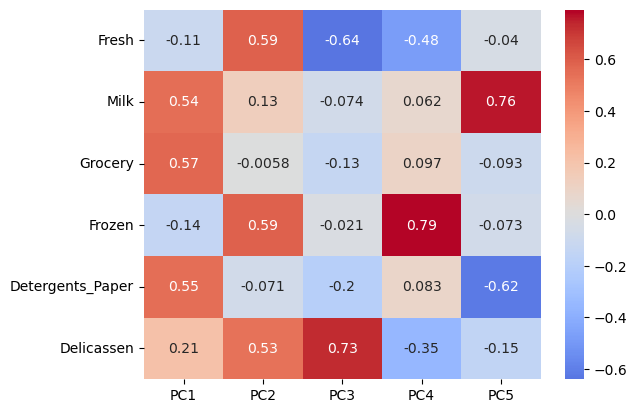

In [28]:
sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

>We will take four principal components because they preserve approximately 92% of the original variance while reducing dimensionality from six features to four. This balances information retention with computational efficiency and helps reduce redundancy before clustering.

#### Final PCA Selection for Clustering with 4 components

In [29]:
from sklearn.decomposition import PCA
pca_final = PCA(n_components=4)
X_pca = pca_final.fit_transform(scaled_df)
pca_final_df = pd.DataFrame(
    X_pca,
    columns=[
        'PC1',
        'PC2',
        'PC3',
        'PC4'
    ]
)
pca_final_df.head()

,PC1,PC2,PC3,PC4
0,1.380383,-0.304727,-0.241062,-1.415719
1,1.438870,0.537468,0.084232,0.030928
2,1.513453,1.232565,0.985306,-0.168522
3,-0.825105,1.210790,0.252141,0.339294
4,0.802897,1.766046,0.312698,-0.234905


In [30]:
explained_variance = pca_final.explained_variance_ratio_
print(explained_variance)

[0.44077752 0.27194917 0.10698428 0.10103287]


In [31]:
cumulative_variance = explained_variance.cumsum()

print(cumulative_variance)

[0.44077752 0.71272669 0.81971097 0.92074384]


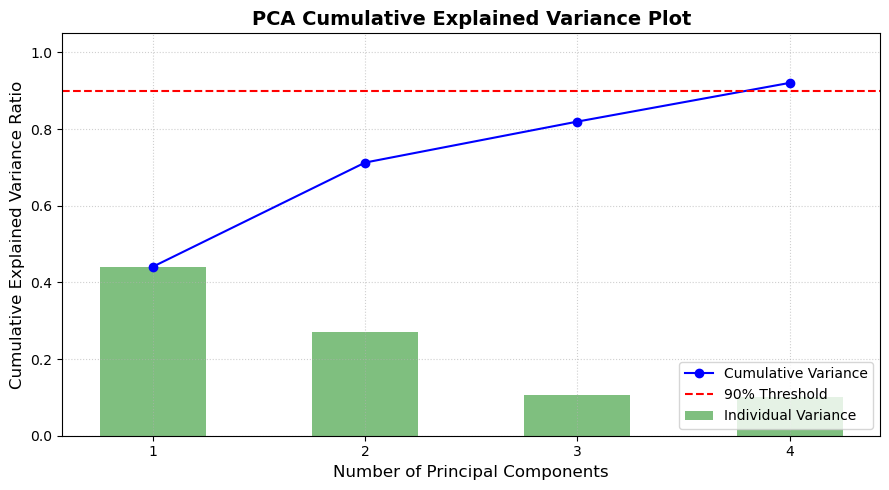

In [32]:
plt.figure(figsize=(9, 5))

# Plot the step or line graph
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='blue', label='Cumulative Variance')
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, color='green', label='Individual Variance',width=0.5)

# Add a threshold line (e.g., 90% variance)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')

# Aesthetics
plt.title('PCA Cumulative Explained Variance Plot', fontsize=14, fontweight='bold')
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance Ratio', fontsize=12)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')


# Display the plot
plt.tight_layout()
plt.show()


# Implementing K-Means

In [33]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

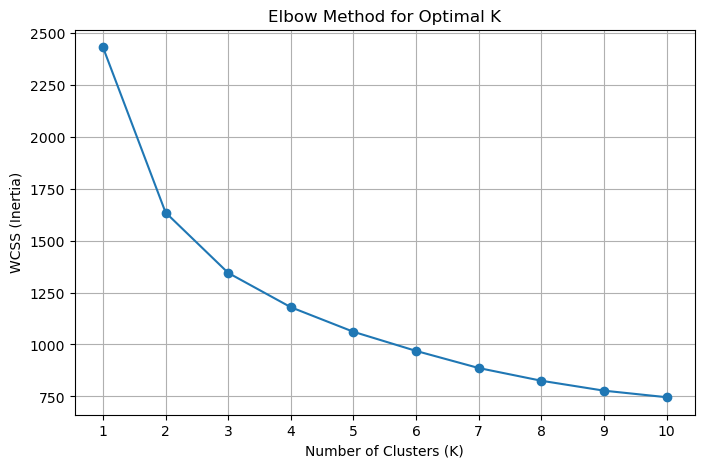

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1,11))
plt.grid(True)

plt.show()

In [35]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca)

    score = silhouette_score(X_pca, labels)

    silhouette_scores.append(score)

## Final Plot of K-Means

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

In [37]:
df["Cluster"] = clusters

In [38]:
df.head(10)

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678,2
1,2,3,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682,2
2,2,3,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632,2
3,1,3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412,1
4,2,3,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718,2
5,2,3,9.149953,9.019180,8.542276,6.502790,7.493317,7.280697,2
6,2,3,9.403190,8.070906,8.850231,6.175867,8.052296,6.302619,0
7,2,3,8.933268,8.508556,9.151333,7.420579,8.108322,7.850493,2
8,1,3,8.693497,8.202208,8.731175,6.054439,7.448334,6.621406,0
9,2,3,8.700681,9.314160,9.845964,7.056175,8.912743,7.649216,2


In [39]:
df["Cluster"].value_counts().sort_index()

Cluster
0     82
1    215
2    143
Name: count, dtype: int64

In [40]:
cols = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

cluster_profile = df.groupby("Cluster")[cols].mean().round(2)

cluster_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,7.03,8.62,9.19,5.86,8.13,5.79
1,8.98,7.35,7.60,7.57,5.50,6.41
2,9.34,9.00,9.27,7.73,7.96,7.56


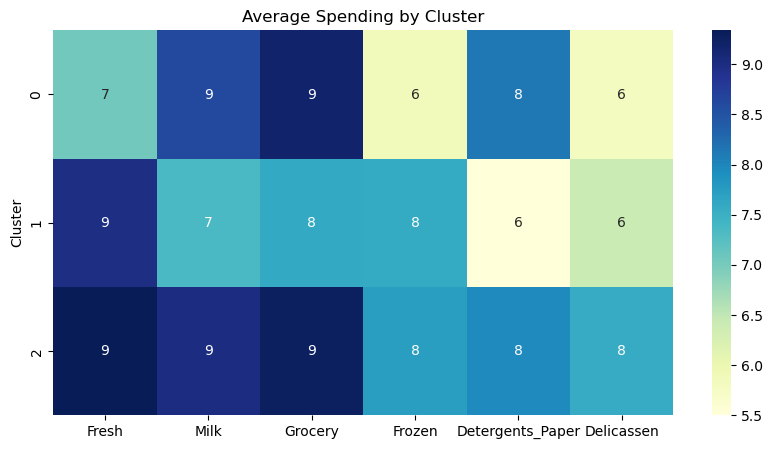

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="YlGnBu",
    fmt=".0f"
)

plt.title("Average Spending by Cluster")
plt.show()

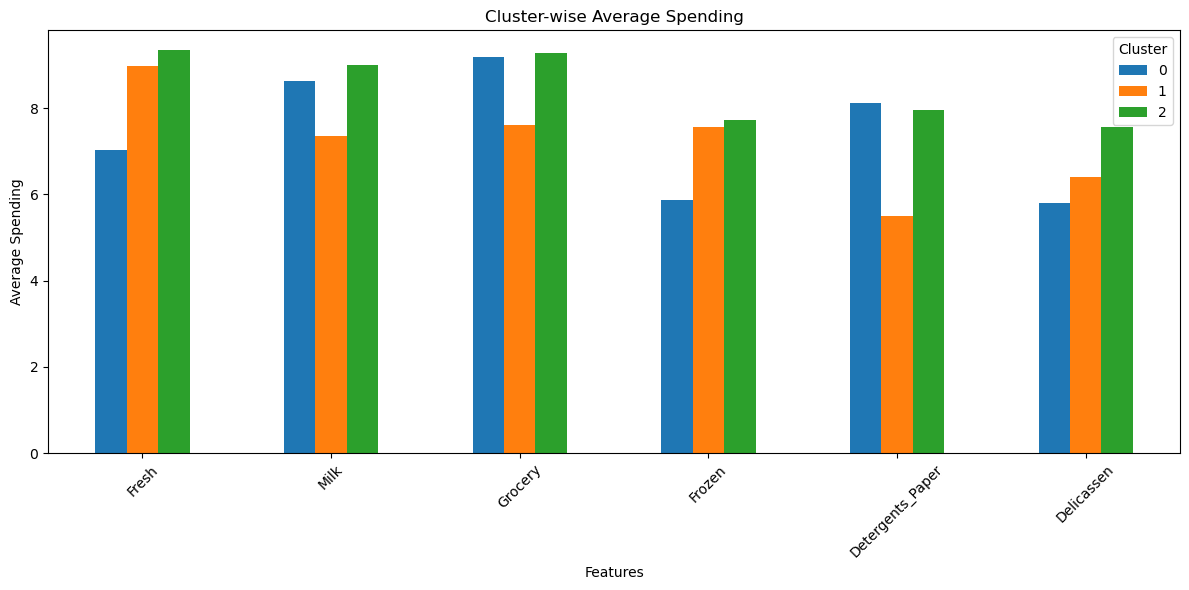

In [46]:
cluster_profile.T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Cluster-wise Average Spending")
plt.xlabel("Features")
plt.ylabel("Average Spending")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

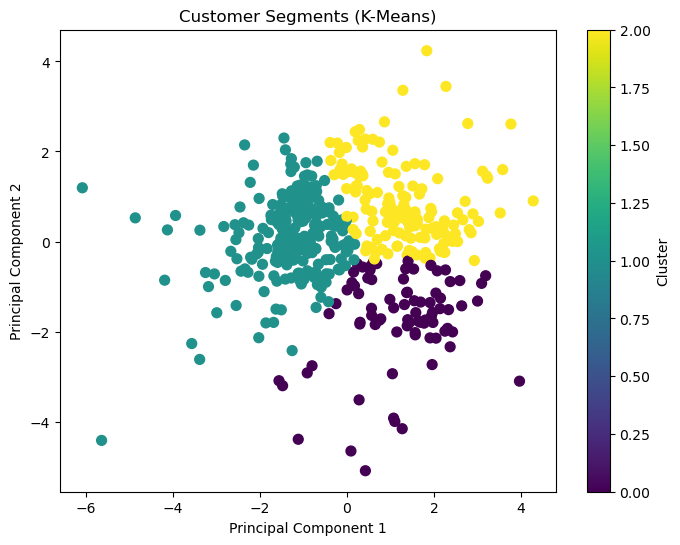

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments (K-Means)")
plt.colorbar(label="Cluster")

plt.show()

### Based on the data
* Cluster 0: Retail & Grocery Customers

* Cluster 1: Fresh Food Buyers

* Cluster 2: High-Value Bulk Buyers

In [44]:
cluster_sizes = df["Cluster"].value_counts().sort_index()

print(cluster_sizes)

Cluster
0     82
1    215
2    143
Name: count, dtype: int64


In [48]:
cluster_names = {
    0: "Retail & Grocery Customers",
    1: "Fresh Food Buyers",
    2: "High-Value Bulk Buyers"
}

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

In [49]:
df["Customer_Segment"]

0          High-Value Bulk Buyers
1          High-Value Bulk Buyers
2          High-Value Bulk Buyers
3               Fresh Food Buyers
4          High-Value Bulk Buyers
                  ...            
435        High-Value Bulk Buyers
436             Fresh Food Buyers
437        High-Value Bulk Buyers
438             Fresh Food Buyers
439    Retail & Grocery Customers
Name: Customer_Segment, Length: 440, dtype: str

In [51]:
df.to_csv("customer_segments.csv", index=False)

# Business Insights

## Cluster 0 – Retail & Grocery Customers

Characteristics

* High spending on Milk, Grocery, and Detergents.
* Lower spending on Fresh and Frozen products.

Business Interpretation

These customers primarily purchase packaged grocery and household products, making them likely retail or convenience-store type buyers.

Marketing Strategy

* Offer discounts on grocery bundles.
* Introduce loyalty programs for repeat purchases.
* Promote household essentials together.

## Cluster 1 – Fresh Food Buyers

Characteristics

* High spending on Fresh and Frozen products.
* Lower spending on Grocery and Detergents.

Business Interpretation

These customers prefer fresh food products and may represent restaurants, cafés, or businesses emphasizing fresh ingredients.

Marketing Strategy

* Provide seasonal offers on fresh produce.
* Bundle Fresh and Frozen items.
* Offer early access to premium fresh products.


## Cluster 2 – High-Value Bulk Buyers

Characteristics

* High spending across nearly all product categories.
* Highest overall purchasing level.

Business Interpretation

These are the most valuable customers and likely buy in bulk or serve large operations.

Marketing Strategy

* Assign dedicated account managers.
* Offer premium memberships.
* Provide volume discounts and exclusive promotions.

# Project Conclusion

This project segmented wholesale customers using K-Means clustering after preprocessing the data with log transformation, standardization, and Principal Component Analysis (PCA). The Elbow Method and Silhouette Score were used to determine the optimal number of clusters. Three meaningful customer segments were identified based on purchasing behavior. Visualizations such as heatmaps, bar charts, and PCA scatter plots helped interpret the clusters. These insights can support targeted marketing, customer retention, and inventory management strategies.

## Part 7: Resume Description

A concise description for your resume could be:

Developed a customer segmentation model using K-Means clustering on the Wholesale Customers dataset. Applied log transformation, StandardScaler, PCA, Elbow Method, and Silhouette Score to identify customer segments. Generated business insights through cluster profiling and visualizations to support targeted marketing strategies.